In [148]:
##*Fish Weight Prediction*

In [149]:
#STEP 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [150]:
#STEP 2: Load Dataset

url = "https://github.com/ybifoundation/Dataset/raw/main/Fish.csv"
df = pd.read_csv(url)

df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


In [151]:
#STEP 3: Basic Data Check

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  159 non-null    int64  
 1   Species   159 non-null    object 
 2   Weight    159 non-null    float64
 3   Height    159 non-null    float64
 4   Width     159 non-null    float64
 5   Length1   159 non-null    float64
 6   Length2   159 non-null    float64
 7   Length3   159 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 10.1+ KB


,0
Category,0
Species,0
Weight,0
Height,0
Width,0
Length1,0
Length2,0
Length3,0


In [152]:
#STEP 4: Encode Categorical Variable (Species)

df = pd.get_dummies(df, columns=['Species'], drop_first=True)
df.head()

,Category,Weight,Height,Width,Length1,Length2,Length3,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,1,242.0,11.5200,4.0200,23.2,25.4,30.0,False,False,False,False,False,False
1,1,290.0,12.4800,4.3056,24.0,26.3,31.2,False,False,False,False,False,False
2,1,340.0,12.3778,4.6961,23.9,26.5,31.1,False,False,False,False,False,False
3,1,363.0,12.7300,4.4555,26.3,29.0,33.5,False,False,False,False,False,False
4,1,430.0,12.4440,5.1340,26.5,29.0,34.0,False,False,False,False,False,False


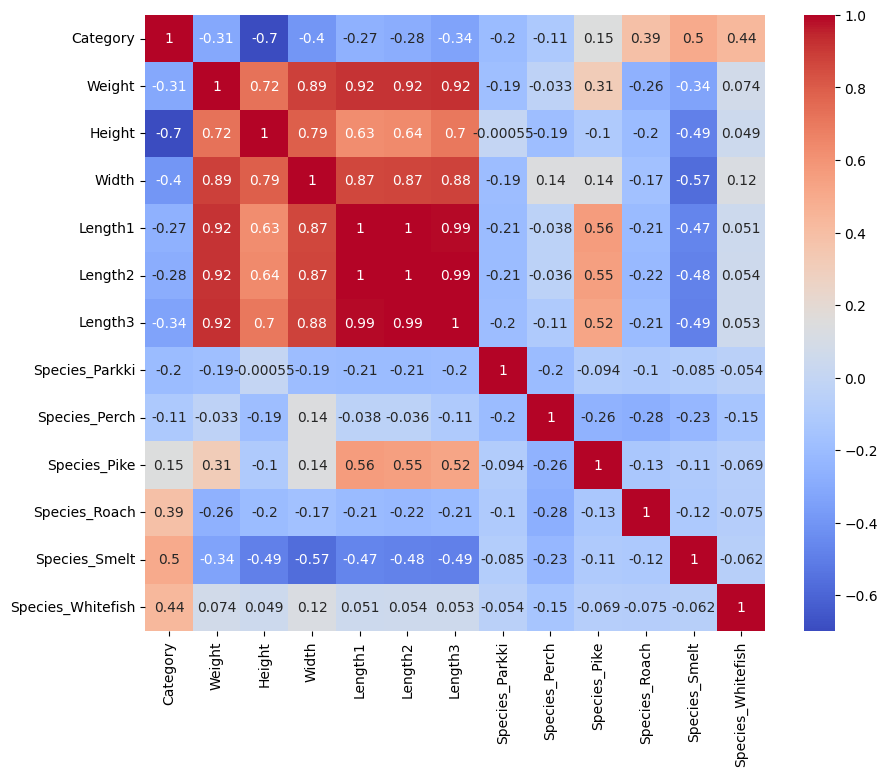

In [153]:
#STEP 5: Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [154]:
#STEP 6: Remove Highly Correlated Features

df = df.drop(['Length1', 'Length2'], axis=1)

In [155]:
#STEP 7: Define Features & Target

X = df.drop('Weight', axis=1)
y = df['Weight']

In [156]:
#STEP 8: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression R2 Score: 0.9445400846844235
Linear Regression MSE: 7888.578802469087


<Figure size 1200x800 with 0 Axes>

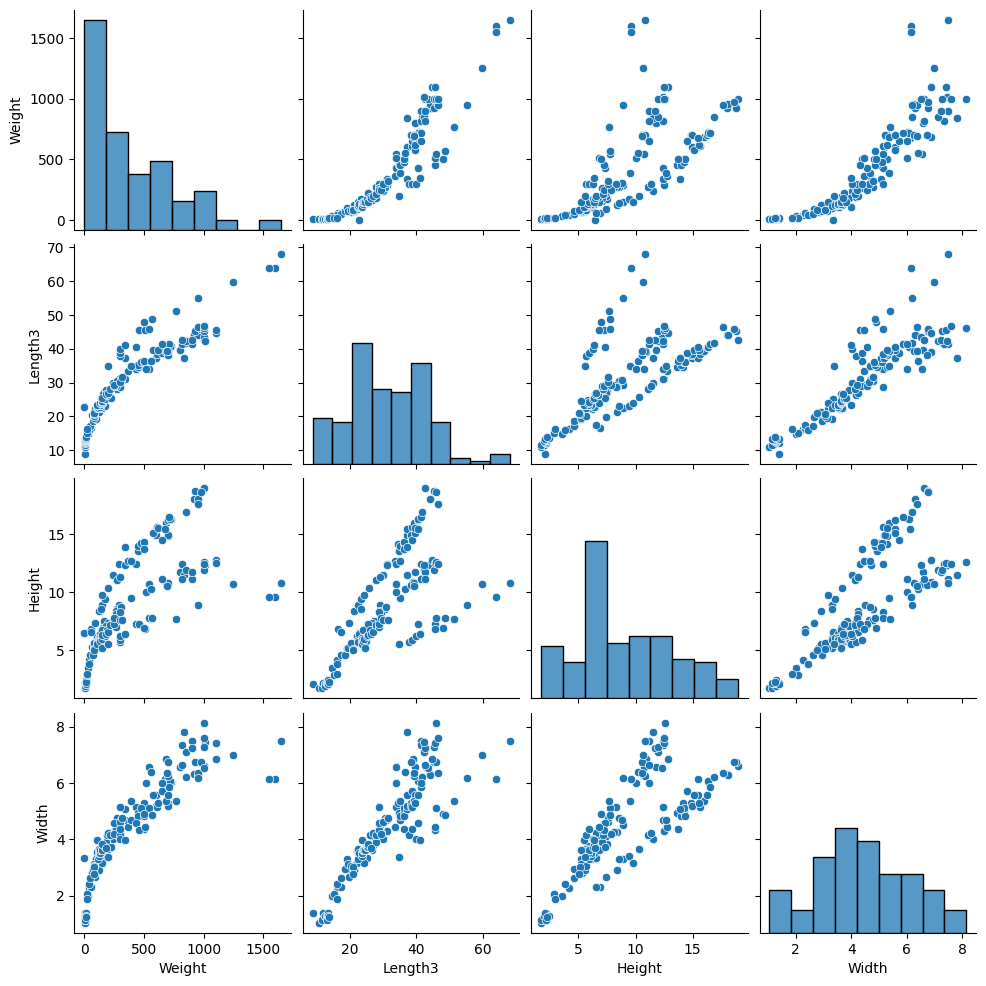

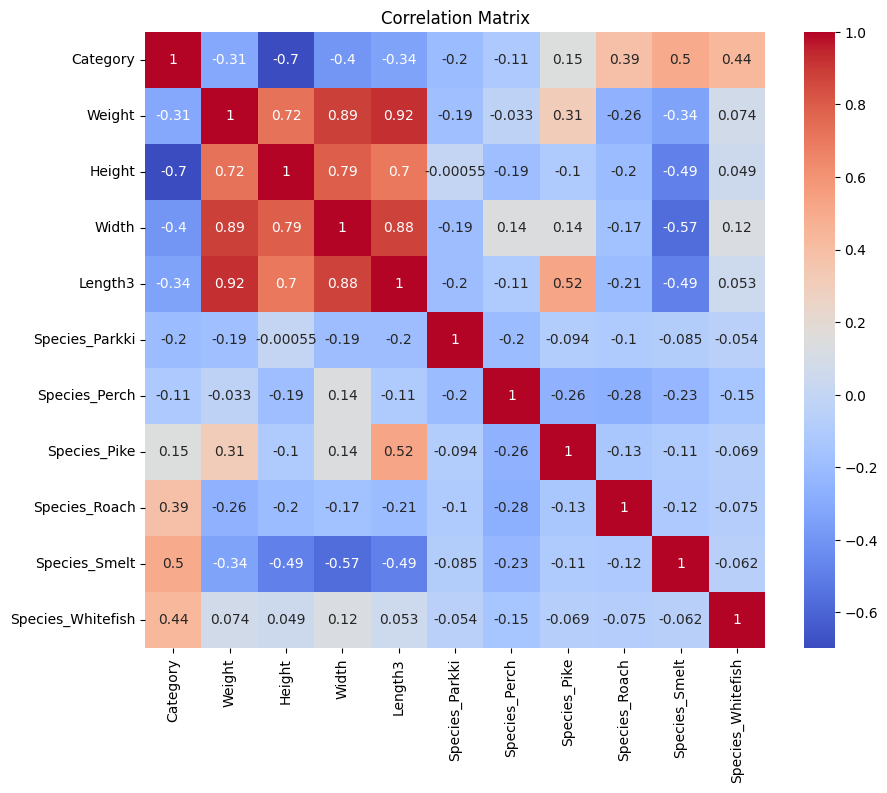

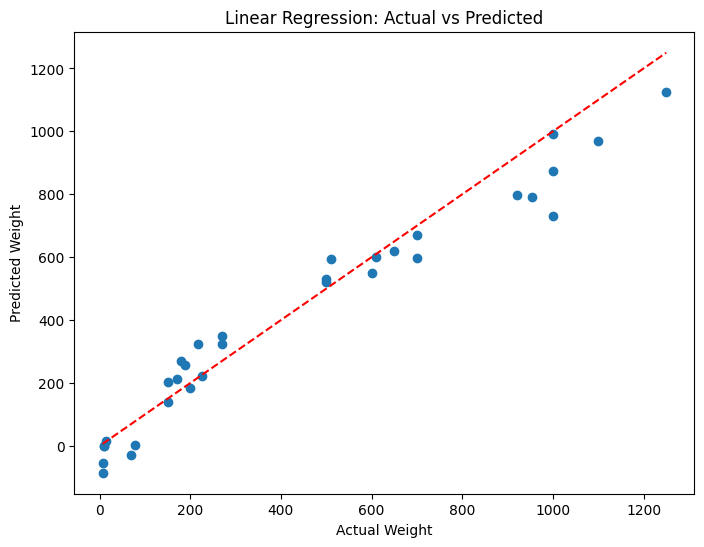

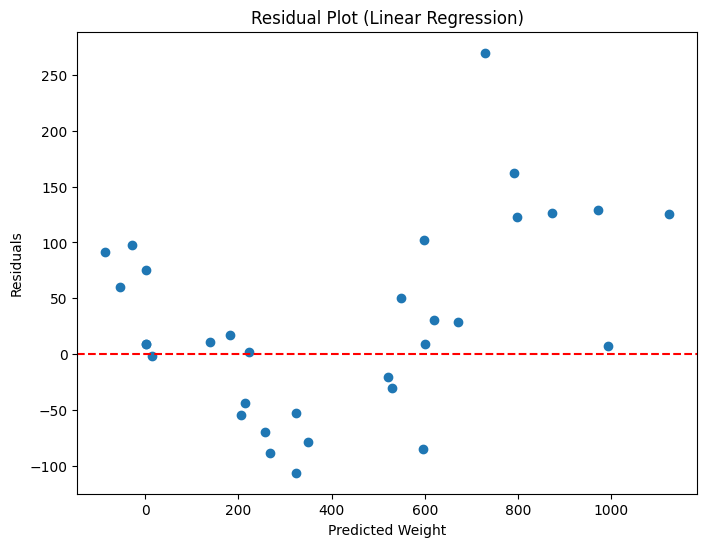

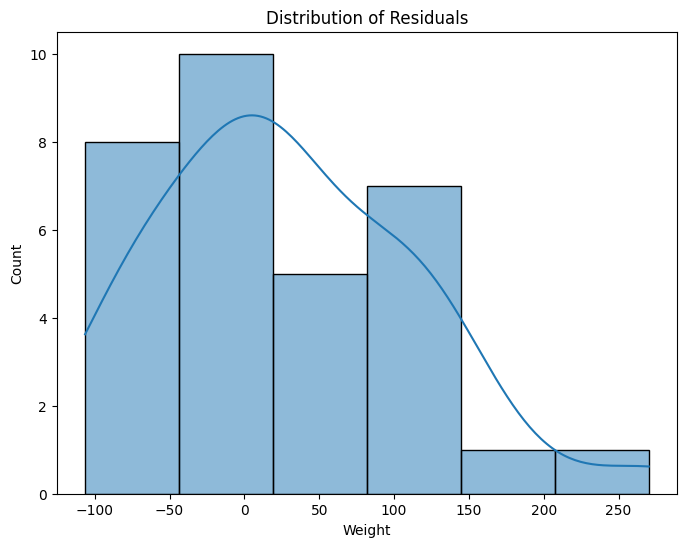

LINEAR REGRESSION RESULTS
R2 Score: 0.9445400846844235
MSE: 7888.578802469087
RMSE: 88.81767167894623


In [157]:
##MODEL 1: Linear Regression (Baseline)

#STEP 9: Train Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))

plt.figure(figsize=(12,8))
sns.pairplot(df[['Weight','Length3','Height','Width']])
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # Perfect prediction line
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

residuals = y_test - y_pred_lr

plt.figure(figsize=(8,6))
plt.scatter(y_pred_lr, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Weight")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

print("LINEAR REGRESSION RESULTS")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

In [158]:
##MODEL 2: Polynomial Regression (Degree = 3)

#STEP 10: Apply StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [159]:
#STEP 11: Apply Polynomial Features (degree = 3)

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [160]:
#STEP 12: Train Polynomial Regression

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial Regression R2 Score:", r2_score(y_test, y_pred_poly))
print("Polynomial Regression MSE:", mean_squared_error(y_test, y_pred_poly))

Polynomial Regression R2 Score: 0.7428431558776063
Polynomial Regression MSE: 36577.806112949635


In [161]:
##MODEL 3: Ridge Regression

#STEP 13: Train Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R2 Score:", r2_score(y_test, y_pred_ridge))
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))

Ridge R2 Score: 0.9509953734716754
Ridge MSE: 6970.383129050357


In [162]:
##MODEL 4: Lasso Regression

#STEP 14: Train Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso R2 Score:", r2_score(y_test, y_pred_lasso))
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))

Lasso R2 Score: 0.9454780482997055
Lasso MSE: 7755.163526753317


In [163]:
#STEP 15: Compare All Models

results = pd.DataFrame({
    'Model': ['Linear', 'Polynomial (deg=3)', 'Ridge', 'Lasso'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ]
})

results

,Model,R2 Score,MSE
0,Linear,0.944540,7888.578802
1,Polynomial (deg=3),0.742843,36577.806113
2,Ridge,0.950995,6970.383129
3,Lasso,0.945478,7755.163527


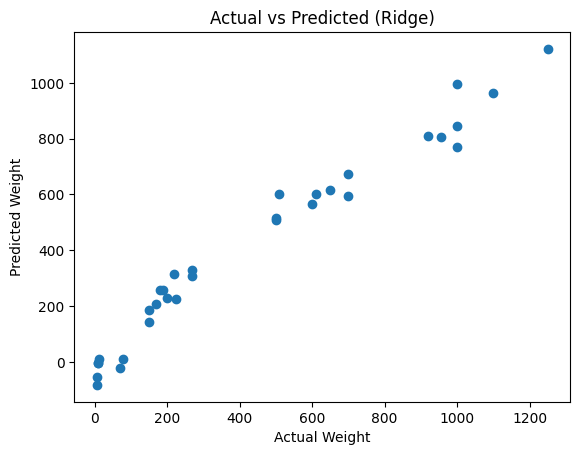

In [164]:
#STEP 16: Plot Actual vs Predicted (Best Model)

plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Actual vs Predicted (Ridge)")
plt.show()